In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import NASNetLarge, InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [119]:
from PIL import Image
import os
import xml.etree.ElementTree as ET

drive_path = os.path.join(os.getcwd(), "../dataset")

# Paths to your dataset
dataset_dir = drive_path + '/filtered/Image'

for cls in os.listdir(dataset_dir):
  for img in os.listdir(dataset_dir + "/" + cls):
    image_file = dataset_dir + "/" + cls + "/" + img
    image = Image.open(image_file)
    annomation = image_file.replace("/Image", "/Annotation")
    annomation = annomation.replace(".jpg", "")
    tree = ET.parse(annomation)
    root = tree.getroot()
    bndbox = root.find(".//bndbox")  # Locate the <bndbox> tag
    xmin = int(bndbox.find("xmin").text)
    ymin = int(bndbox.find("ymin").text)
    xmax = int(bndbox.find("xmax").text)
    ymax = int(bndbox.find("ymax").text)

    crop_coords = (xmin, ymin, xmax, ymax)  # (x_min, y_min, x_max, y_max)

    cropped_image = image.crop(crop_coords)
    cropped_folder = image_file.split("/Image")[0] + "/ImageCropped/" + cls
    if not os.path.exists(cropped_folder):
      os.mkdir(cropped_folder)
    cropped_filepath = cropped_folder + "/" + img
    cropped_image.save(cropped_filepath)


In [2]:
# Step 1: Create the model for each angle (using pre-trained NASNet Large and Inception V3)
def create_feature_extractor(input_shape):
    # NASNet Large
    nasnet = NASNetLarge(input_shape=input_shape, include_top=False, weights='imagenet')
    nasnet.trainable = False  # Freeze the layers

    # Inception V3
    inception = InceptionV3(input_shape=input_shape, include_top=False, weights='imagenet')
    inception.trainable = False  # Freeze the layers

    return nasnet, inception


In [13]:
# Step 2: Fusion Layer (combines features from all angles)
def feature_fusion_layer(*features):
    # Concatenate the features along the last axis (depth)
    fused_features = layers.concatenate(features)
    return fused_features


In [88]:
# Step 3: Create the complete model
def create_model(input_shape):
    # Define input layers for each angle (e.g., front, side, back, top)
    inputt = layers.Input(shape=input_shape)

    # Create the feature extractors
    nasnet, inception = create_feature_extractor(input_shape)

    # Pass each view through NASNet Large and Inception V3
    nasnet_inp = nasnet(inputt)
    inception_inp = inception(inputt)

    nasnet_inp = layers.GlobalAveragePooling2D()(nasnet_inp)
    inception_inp = layers.GlobalAveragePooling2D()(inception_inp)

    # Step 4: Fuse the features from all angles
    fused_features = feature_fusion_layer(
        nasnet_inp, inception_inp,
    )

    # Step 5: Add Classification Layer
    x = layers.Dense(1024, activation='relu')(fused_features)
    x = layers.Dropout(0.5)(x)
    output = layers.Dense(10, activation='softmax')(x)  # 10 classes

    # Final model
    model = models.Model(inputs=[inputt], outputs=output)

    return model


In [124]:
# Define input shape
input_shape = (224, 224, 3)

# Step 6: Compile the model
model = create_model(input_shape)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Summary of the model architecture
# model.summary()



In [78]:
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# import numpy as np

# import os
# drive_path = os.path.join(os.getcwd(), "../dataset")
# input_shape = (224, 224, 3)

# # Paths to your dataset
# dataset_dir = drive_path + '/filtered/ImageMultiView'


# # Custom data generator to handle multiple views (front, side, back, top)
# class MultiViewImageDataGenerator(ImageDataGenerator):
#     def __init__(self, batch_size, target_size=(224, 224)):
#         self.image_directory = dataset_dir
#         self.batch_size = batch_size
#         self.target_size = target_size
#         self.datagen = ImageDataGenerator(
#             rescale=1.0/255,
#             rotation_range=20,
#             width_shift_range=0.2,
#             height_shift_range=0.2,
#             shear_range=0.2,
#             zoom_range=0.2,
#             horizontal_flip=True,
#             fill_mode='nearest',
#             validation_split=0.2
#         )

#         self.front_gen = self.datagen.flow_from_directory(
#             self.image_directory + '/front',
#             target_size=target_size,
#             batch_size=batch_size,
#             class_mode='categorical',
#             shuffle=True
#         )
#         self.front_gen_val = self.datagen.flow_from_directory(
#             self.image_directory + '/front',
#             target_size=target_size,
#             batch_size=batch_size,
#             class_mode='categorical',
#             shuffle=True,
#           subset='validation'
#         )

#         self.side_gen = self.datagen.flow_from_directory(
#             self.image_directory + '/side',
#             target_size=target_size,
#             batch_size=batch_size,
#             class_mode='categorical',
#             shuffle=True
#         )
#         self.side_gen_val = self.datagen.flow_from_directory(
#             self.image_directory + '/side',
#             target_size=target_size,
#             batch_size=batch_size,
#             class_mode='categorical',
#             shuffle=True,
#           subset='validation'
#         )

#     def __len__(self):
#         # The number of steps per epoch
#         return min(len(self.front_gen), len(self.side_gen))

#     def __getitem__(self, index):
#         front_images, front_labels = self.front_gen[index]
#         side_images, side_labels = self.side_gen[index]

#         # Ensure that labels for each view are the same
#         assert np.array_equal(front_labels, side_labels)

#         # Return a dictionary for multi-input model
#         return {
#             'front': front_images,
#             'side': side_images,
#         }, front_labels

#     def __getitem_val__(self):
#         front_images_val, front_labels_val = self.front_gen_val[0]
#         side_images_val, side_labels_val = self.side_gen_val[0]
#         # Ensure that labels for each view are the same
#         print(front_labels_val.shape, side_labels_val.shape)
#         # assert np.array_equal(front_labels_val, side_labels_val)
#         return (
#             self.front_gen_val,
#             self.side_gen_val
#         )


In [125]:
# import os
drive_path = os.path.join(os.getcwd(), "../dataset")
input_shape = (224, 224, 3)
target_size = (224, 224)
batch_size = 32

# # Paths to your dataset
image_directory = drive_path + '/filtered/ImageCropped'

datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    image_directory,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)
val_gen = datagen.flow_from_directory(
    image_directory,
    target_size=target_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True,
  subset='validation'
)

# side_gen = datagen.flow_from_directory(
#     image_directory + '/side',
#     target_size=target_size,
#     batch_size=batch_size,
#     class_mode='categorical',
#     shuffle=True
# )
# side_gen_val = datagen.flow_from_directory(
#     image_directory + '/side',
#     target_size=target_size,
#     batch_size=batch_size,
#     class_mode='categorical',
#     shuffle=True,
#   subset='validation'
# )

Found 1657 images belonging to 10 classes.
Found 328 images belonging to 10 classes.


In [126]:

# train_gen = MultiViewImageDataGenerator(batch_size=32)
# val_gen = MultiViewImageDataGenerator(batch_size=32)
# Step 8: Train the model
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    steps_per_epoch=train_gen.samples // train_gen.batch_size,
    validation_steps=val_gen.samples // val_gen.batch_size
)


Epoch 1/10
51/51 [==============================] - 43s 500ms/step - loss: 0.5612 - accuracy: 0.9071 - val_loss: 0.2767 - val_accuracy: 0.9531
Epoch 2/10
51/51 [==============================] - 18s 350ms/step - loss: 0.1476 - accuracy: 0.9723 - val_loss: 0.1324 - val_accuracy: 0.9812
Epoch 3/10
51/51 [==============================] - 18s 347ms/step - loss: 0.2357 - accuracy: 0.9662 - val_loss: 0.0596 - val_accuracy: 0.9906
Epoch 4/10
51/51 [==============================] - 18s 352ms/step - loss: 0.1612 - accuracy: 0.9735 - val_loss: 0.2181 - val_accuracy: 0.9750
Epoch 5/10
51/51 [==============================] - 18s 357ms/step - loss: 0.1935 - accuracy: 0.9698 - val_loss: 0.1814 - val_accuracy: 0.9781
Epoch 6/10
51/51 [==============================] - 18s 349ms/step - loss: 0.2334 - accuracy: 0.9680 - val_loss: 0.1098 - val_accuracy: 0.9781
Epoch 7/10
51/51 [==============================] - 18s 348ms/step - loss: 0.2455 - accuracy: 0.9655 - val_loss: 0.0601 - val_accuracy: 0.9906

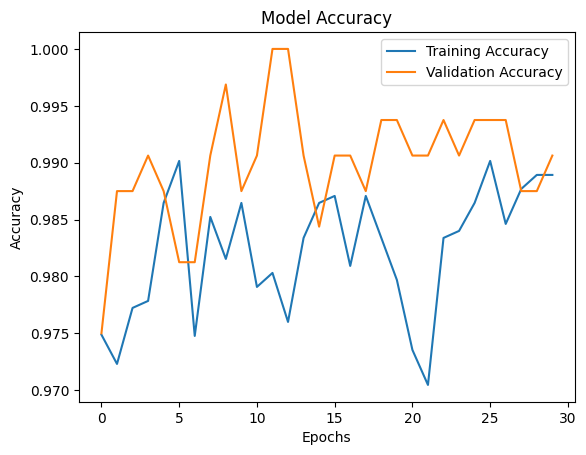

In [122]:

# Step 9: Plot Accuracy Graph
import matplotlib.pyplot as plt

# Plot the accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
